# REAL ESTATE PRICE PREDICTION -EXPLORATORY Data Analysis (EDA)

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0] / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Initial Setup

In [2]:
def load_train_data():
    # Works in both notebooks and scripts
    # In notebooks, Path().resolve() gives the current working directory
    project_root = Path().resolve().parent  # Go up one level from notebook directory
    file_path = project_root / "data" / "raw" / "train.csv"
    return pd.read_csv(file_path)

# Data Loading and Initial Inspection

In [3]:
df = load_train_data()

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df = load_train_data()

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#  features understanding


= number of rows ,useless ID
2  binary feature
3-20 categorical
>50 numeric/ continuous

In [5]:
pd.DataFrame(df.columns, columns=["Feature Name"])
for col in df.columns:
    print(col, "→", df[col].nunique())

Id → 1460
MSSubClass → 15
MSZoning → 5
LotFrontage → 110
LotArea → 1073
Street → 2
Alley → 2
LotShape → 4
LandContour → 4
Utilities → 2
LotConfig → 5
LandSlope → 3
Neighborhood → 25
Condition1 → 9
Condition2 → 8
BldgType → 5
HouseStyle → 8
OverallQual → 10
OverallCond → 9
YearBuilt → 112
YearRemodAdd → 61
RoofStyle → 6
RoofMatl → 8
Exterior1st → 15
Exterior2nd → 16
MasVnrType → 3
MasVnrArea → 327
ExterQual → 4
ExterCond → 5
Foundation → 6
BsmtQual → 4
BsmtCond → 4
BsmtExposure → 4
BsmtFinType1 → 6
BsmtFinSF1 → 637
BsmtFinType2 → 6
BsmtFinSF2 → 144
BsmtUnfSF → 780
TotalBsmtSF → 721
Heating → 6
HeatingQC → 5
CentralAir → 2
Electrical → 5
1stFlrSF → 753
2ndFlrSF → 417
LowQualFinSF → 24
GrLivArea → 861
BsmtFullBath → 4
BsmtHalfBath → 3
FullBath → 4
HalfBath → 3
BedroomAbvGr → 8
KitchenAbvGr → 4
KitchenQual → 4
TotRmsAbvGrd → 12
Functional → 7
Fireplaces → 4
FireplaceQu → 5
GarageType → 6
GarageYrBlt → 97
GarageFinish → 3
GarageCars → 5
GarageArea → 441
GarageQual → 5
GarageCond → 5
PavedDr

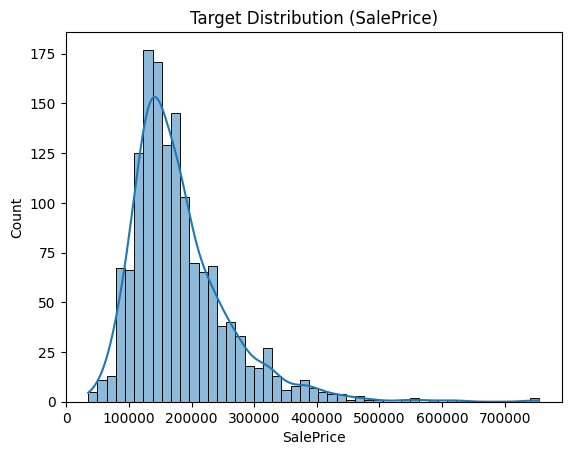

In [6]:


sns.histplot(df["SalePrice"], kde=True)
plt.title("Target Distribution (SalePrice)")
plt.show()

# missing values


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

# 📊 Categorical vs Target

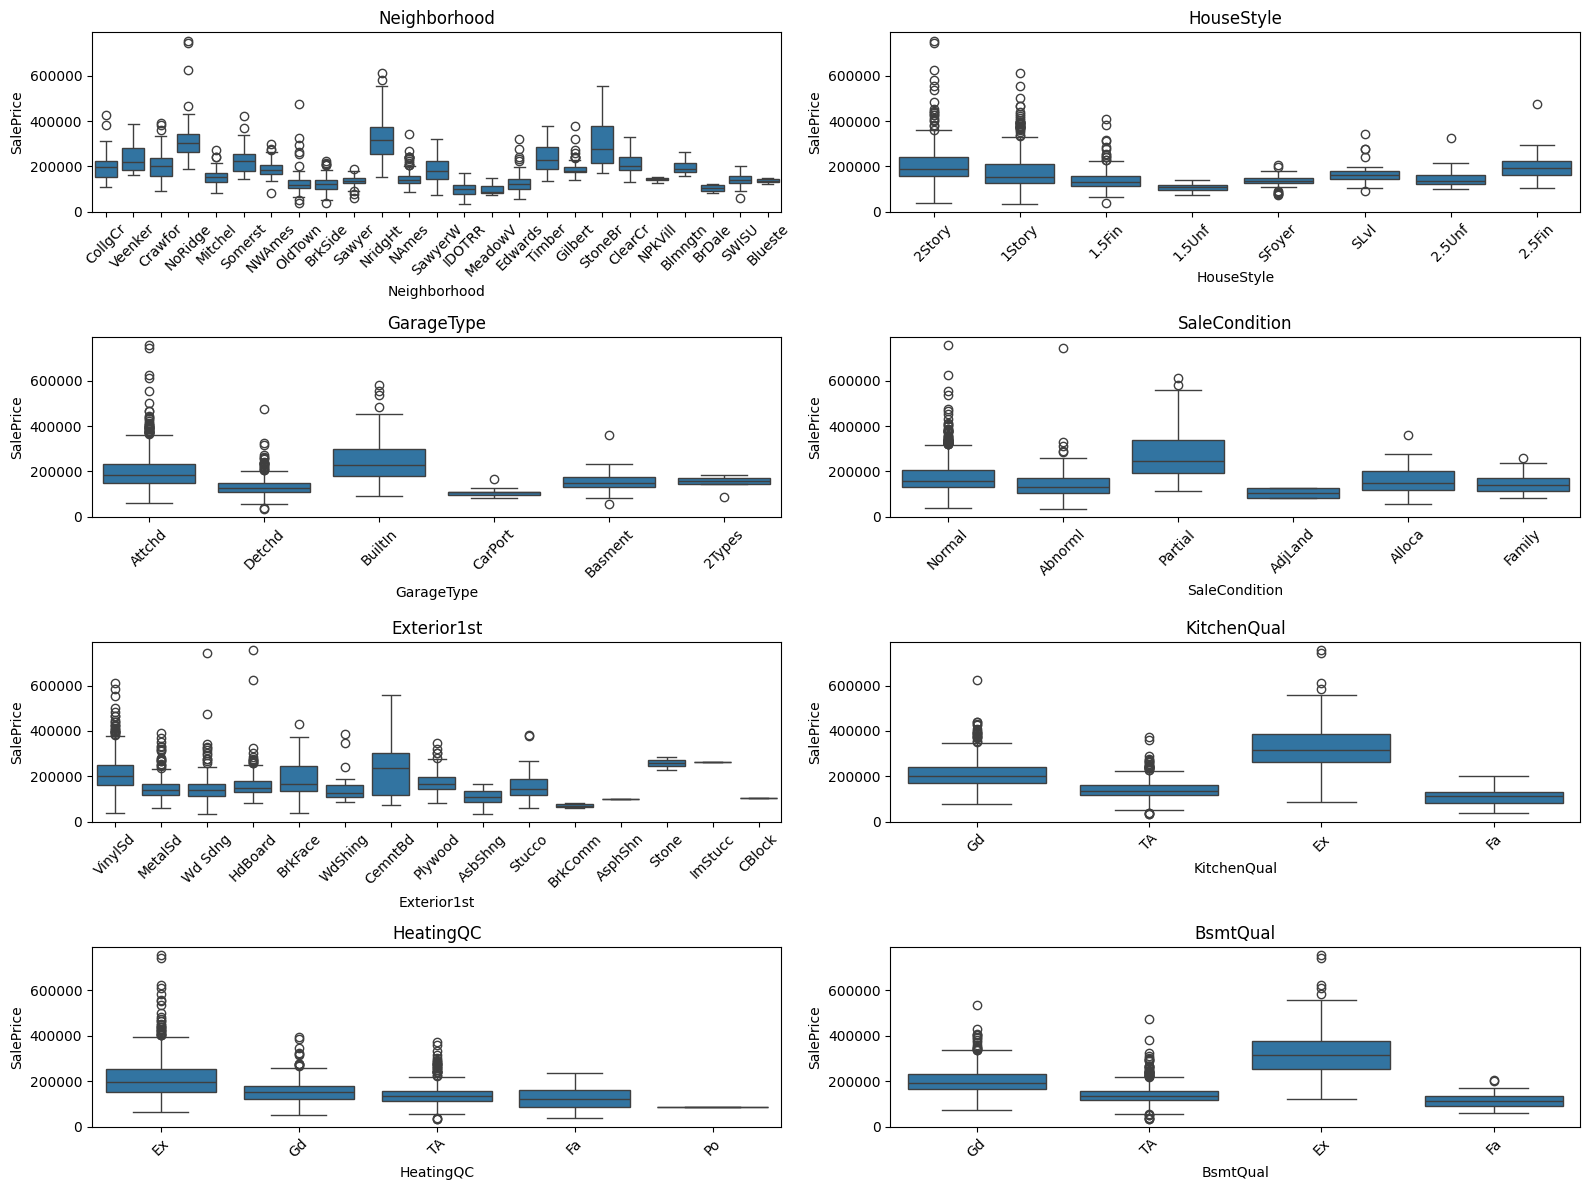

In [8]:
selected_cols = [
    "Neighborhood",
    "HouseStyle",
    "GarageType",
    "SaleCondition",
    "Exterior1st",
    "KitchenQual",
    "HeatingQC",
    "BsmtQual"
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col], y=df["SalePrice"])
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

# Correlation Matrix

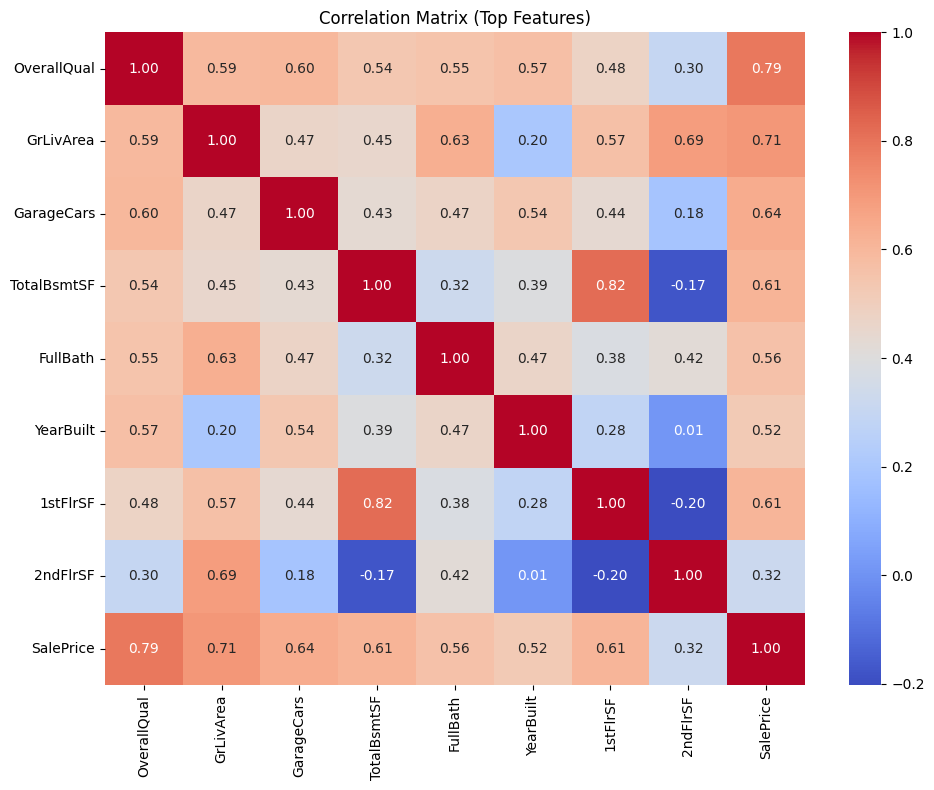

In [9]:
selected_cols = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "1stFlrSF",
    "2ndFlrSF",
    "SalePrice"
]

# Filter to only columns that exist
selected_cols = [col for col in selected_cols if col in df.columns]

corr = df[selected_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix (Top Features)")
plt.tight_layout()
plt.show()

# detect and remove outliers using IQR method

In [10]:

Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < lower_bound) | (df["SalePrice"] > upper_bound)]
print("Number of outliers:", len(outliers))
df_clean = df[
    (df["SalePrice"] >= lower_bound) &
    (df["SalePrice"] <= upper_bound)
]


Number of outliers: 61


# some  feature  engineering
total living space = bigger house bigger price ,
house age = older cheaper,
overall score = quality + condition
bigger gararge = more expensive

In [11]:
# Feature Engineering Implementation

# Make a proper copy to avoid SettingWithCopyWarning
df_engineered = df_clean.copy()

# Get numeric columns for reference
num_cols = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col != "SalePrice"]

print("Numeric columns available:", num_cols)

# 1. Total Living Space (proxy: GrLivArea + TotalBsmtSF)
if "GrLivArea" in df_engineered.columns and "TotalBsmtSF" in df_engineered.columns:
    df_engineered["TotalSF"] = df_engineered["GrLivArea"] + df_engineered["TotalBsmtSF"]
    print("✓ Created TotalSF (total living space)")

# 2. House Age (from YearBuilt)
if "YearBuilt" in df_engineered.columns:
    df_engineered["HouseAge"] = 2024 - df_engineered["YearBuilt"]
    print("✓ Created HouseAge")

# 3. Overall Score (quality + condition proxy)
if "OverallQual" in df_engineered.columns and "OverallCond" in df_engineered.columns:
    df_engineered["OverallScore"] = df_engineered["OverallQual"] * df_engineered["OverallCond"]
    print("✓ Created OverallScore (quality * condition)")

# 4. Garage Size Indicator
if "GarageArea" in df_engineered.columns and "GarageCars" in df_engineered.columns:
    df_engineered["GarageScore"] = df_engineered["GarageArea"] * df_engineered["GarageCars"]
    print("✓ Created GarageScore")

print("\nNew engineered features:")
print(df_engineered[["TotalSF", "HouseAge", "OverallScore", "GarageScore"]].head())

Numeric columns available: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
✓ Created TotalSF (total living space)
✓ Created HouseAge
✓ Created OverallScore (quality * condition)
✓ Created GarageScore

New engineered features:
   TotalSF  HouseAge  OverallScore  GarageScore
0     2566        21            35         1096
1     2524        48            48          920
2     2706        23            35         1216
3     2473       109            35         1926
4     3343        24            40         2508


## Model comparison — three regressors

Same three models as `src/models/train.py`: **LinearRegression**, **RandomForestRegressor**, **GradientBoostingRegressor**. RMSE on train / validation / test (70% / 15% / 15%).

Run the next cell: it loads `src/artifacts/models_metrics.json` if present (from training), otherwise retrains and then **plots** the grouped bar chart.

Loaded metrics from C:\project 2\src\artifacts\models_metrics.json


,model,train_rmse,val_rmse,test_rmse
0,LinearRegression,33507.884002,27100.733395,37796.672086
1,RandomForestRegressor,12690.537084,25263.630423,27654.949293
2,GradientBoostingRegressor,19061.057065,26392.401339,27186.901007


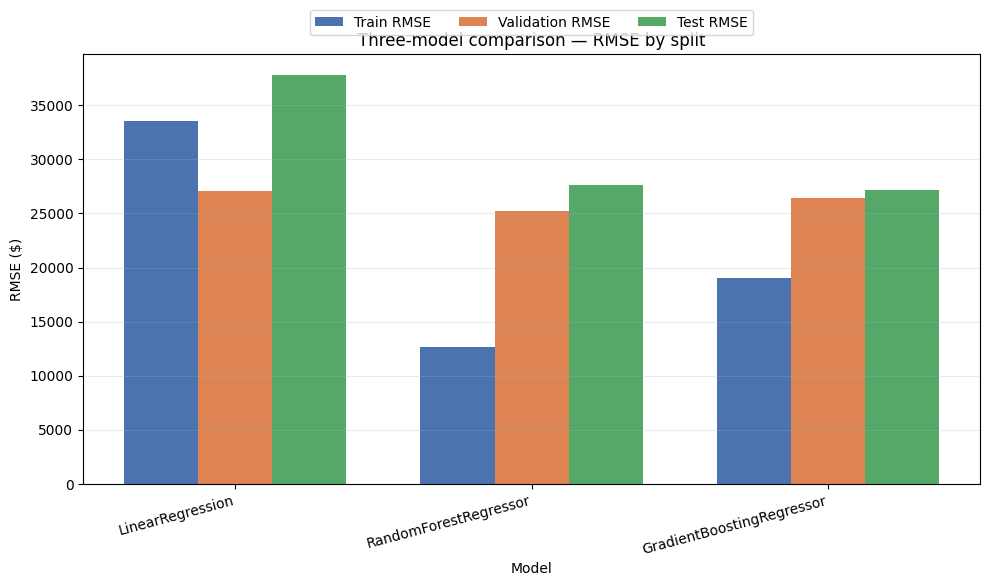

Best validation RMSE: RandomForestRegressor (project saves this as artifacts/best_model.joblib)


In [12]:
from pathlib import Path
import json
import sys

from IPython.display import display

# Repo root (kernel cwd: `notebooks/` or project root)
_root = Path.cwd().resolve()
ROOT = _root.parent if _root.name == "notebooks" else _root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Prefer metrics saved by `python -m src.models.train` (see src/artifacts/models_metrics.json)
METRICS_PATHS = [
    ROOT / "src" / "artifacts" / "models_metrics.json",
    ROOT / "artifacts" / "models_metrics.json",
]

metrics_df = None
for path in METRICS_PATHS:
    if path.is_file():
        with open(path, encoding="utf-8") as f:
            raw = json.load(f)
        metrics_df = pd.DataFrame(raw).rename(columns={"model_name": "model"})
        print(f"Loaded metrics from {path}")
        break

if metrics_df is None:
    from src.data.clean_data import prepare_training_dataframe
    from src.data.load_data import load_train_data
    from src.models.split_data import select_features, split_data
    from src.models.preprocess import build_preprocessor
    from src.models.train import evaluate_model

    df_raw = load_train_data()
    df_prepared = prepare_training_dataframe(df_raw)
    X, y = select_features(df_prepared)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    preprocessor = build_preprocessor(use_scaler=False)
    models = {
        "LinearRegression": LinearRegression(),
        "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
    }
    results = []
    for model_name, model in models.items():
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        results.append(
            evaluate_model(
                name=model_name,
                pipeline=pipe,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                X_test=X_test,
                y_test=y_test,
            )
        )
    metrics_df = pd.DataFrame(
        [
            {
                "model": r["model_name"],
                "train_rmse": r["train_rmse"],
                "val_rmse": r["val_rmse"],
                "test_rmse": r["test_rmse"],
            }
            for r in results
        ]
    )
    print("No cached models_metrics.json — computed metrics by retraining.")

display(metrics_df)

m = metrics_df.set_index("model")
x = np.arange(len(m))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, m["train_rmse"], width, label="Train RMSE", color="#4C72B0")
ax.bar(x, m["val_rmse"], width, label="Validation RMSE", color="#DD8452")
ax.bar(x + width, m["test_rmse"], width, label="Test RMSE", color="#55A868")

ax.set_ylabel("RMSE ($)")
ax.set_xticks(x)
ax.set_xticklabels(m.index, rotation=15, ha="right")
ax.set_xlabel("Model")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=3)
ax.grid(axis="y", alpha=0.25)
ax.set_title("Three-model comparison — RMSE by split")
plt.tight_layout()
plt.show()

best = metrics_df.loc[metrics_df["val_rmse"].idxmin(), "model"]
print(f"Best validation RMSE: {best} (project saves this as artifacts/best_model.joblib)")